# Projet optimisation : effacement

## Etude du problème d'optimisation
1) La facture d'électricité pour un jour correspond à l'énergie consommée et le tarif correspondant. Notre journée étant divisée en N intervalle $\Delta$t, la facture correspond finalement à la somme des N énergies multipliés par le coût pendant cette durée:

$$
 \begin{aligned}
 \sum_{i=1}^N  \Delta t \ c_{i} P_{i} 
\end{aligned}
$$

2) Si $$ \Delta t -> 0, T_{i+1}= T_{i} $$
$$ \Delta t -> +\infty \ , T_{i+1}= \frac{b\ P_{i} + h \ T_{i}^{e}}{k +h } $$
On arrive à une température d'équilibre où **b caracterise l'efficacité du chauffage** et **h la qualité de l'isolation par rapport à l'exterieur**. 
k carastérise l'absence de rayonnement du soleil à l'intérieur de la pièce. 
Modélisation semble raisonnable. 


3) $$ Soit \ f: x -> \Delta t \ \sum_{i=0}^N c_{i} x_{i} $$
Les variables de décision x sont les N+1 puissances des N instants (ou périodes) considérés. Elles sont au nombre de N+1. On cherche à minimiser f sous les contraintes suivantes:
$$ c_{eq}(x)= $$
$$ c_{in}(x) = $$
   

4)

 ## Etude et résolution numérique du problème individuel
 5)

6) 

In [3]:
import marimo as mo
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
import numpy as np


In [26]:
def T_ext(t): 
    return 4 + 8* np.exp(-(t-12)**2/40)

def Coût(c_cr,c_pl,N:int):
    t = 23 #heure de départ
    "Construction du coût et des indices d'occurence pour les heures de présence qui seront utilisées par la suite"""
    Cout =[]
    temps = [] 
    i_occur = [] 
    
    for i in range(N+1):
        temps.append(t%24) 
        if 0<= t%24 <=6 or 12<= t%24<=14: #tarif heure creuse
            Cout.append(c_cr)
        elif 6<t%24<12 or 14<t%24<24 : #tarif heure pleine
            Cout.append(c_pl)
            
        if 7<=t%24<=9 or 18<=t%24<=23: # indice des horaires de présence 
            i_occur.append(i) 
            
        t+=dt
    return Cout, temps, i_occur

c_cr = 1
c_pl = 3/2
dt = 0.5
N = int(24/dt)
t_0= 23
P_M = 5000  
T_m = 18 # en degré celcius
T_M = 30
T_in = T_m
h = 0.05 # en heure -1
k = 0.01 # en heure -1
b = 1/500 # en C/Wh
Cout, temps, i_occur = Coût(c_cr, c_pl,N)

def solve_effacement():
    """ Construction du solveur"""

    P = ca.SX.sym('P', N + 1 ) # car on a P0,..., PN
    T = ca.SX.sym('T', N + 1)
    

    nvar = 2*(N+1)
    lbx = []
    ubx = []
    # Bounds on P
    lbx += [0.0]*(N+1)
    ubx += [P_M]*(N+1)
    # Bounds on T : il faut gérer les cas où les T sont bornées ou pas
    
    for i in range (N+1):
        if i in i_occur:
            
            lbx += [T_m]
            ubx += [T_M]
        else:
            lbx += [-np.inf]
            ubx += [np.inf]
            
    


    x = ca.vertcat(
        ca.reshape(P, N+1, 1),
        ca.reshape(T, N+1, 1),
    )

    # Objective
    
    cost = dt*ca.dot(Cout,P)

    g = []
    lbg = []
    ubg = []

    # Constraint 1: température moyenne relation de récurrence
    i = 0

    for i in range(N ):   
        g.append(T[i+1] - np.exp(-(k+h)*dt)*T[i]- (1-np.exp(-(k+h)*dt))/(k+h)*(b*P[i] + h*T_ext(temps[i]))) 
        lbg.append(0.0)
        ubg.append(0.0)

    # Constraint 2: température initiale et puissance terminale
    g.append(T[0])
    lbg.append(T_m)
    ubg.append(T_m)
    g.append(P[N])
    lbg.append(0)
    ubg.append(0)

    

    g = ca.vertcat(*g)

    lp =  {'x': x, 'f': cost, 'g': g}
    solver = ca.qpsol('s', 'highs', lp)

    sol =  solver(
        x0 = np.ones(nvar),
        lbx= lbx,
        ubx= ubx,
        lbg= lbg,
        ubg= ubg,
    )

    P = sol['x'][:N+1]
    T = sol['x'][N+1:]

    return {
        'P' : ca.reshape(P, N+1,1),
        'T' : ca.reshape(T, N+1 ,1),
    }

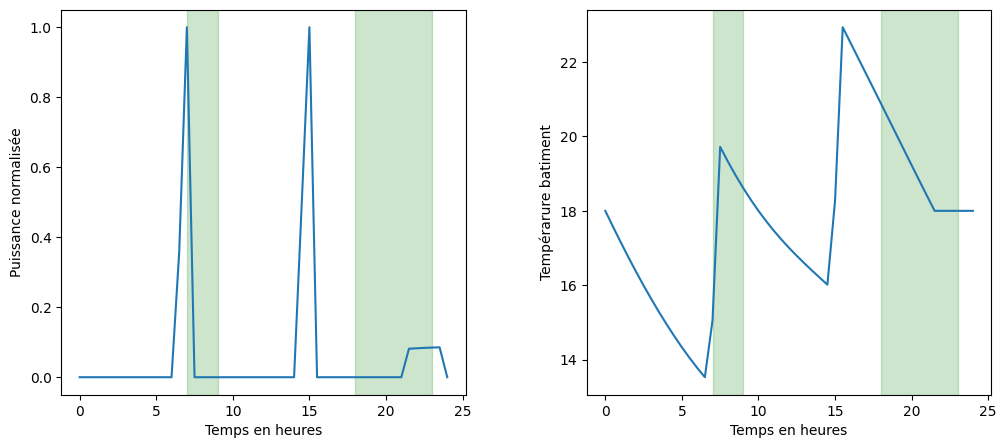

In [27]:
sol_temp = solve_effacement()
temps_heures = np.arange(N+1) * dt # pour avoir le temps en heure
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))  
fig.subplots_adjust(wspace=0.3)  
axs[0].plot(temps_heures,np.array(sol_temp['P']/P_M).flatten())
axs[0].axvspan(7,9, color = "green", alpha = 0.2, label = "occupé")
axs[0].axvspan(18,23, color = "green", alpha = 0.2)

axs[1].plot(temps_heures,np.array(sol_temp['T']).flatten())
axs[1].axvspan(7,9, color = "green", alpha = 0.2, label = "occupé")
axs[1].axvspan(18,23, color = "green", alpha = 0.2)
axs[0].set_ylabel("Puissance normalisée")
axs[0].set_xlabel("Temps en heures")
#axs[1].plot(sol_temp['T'].T)
axs[1].set_ylabel("Tempérarure batiment")
axs[1].set_xlabel("Temps en heures")
plt.show()

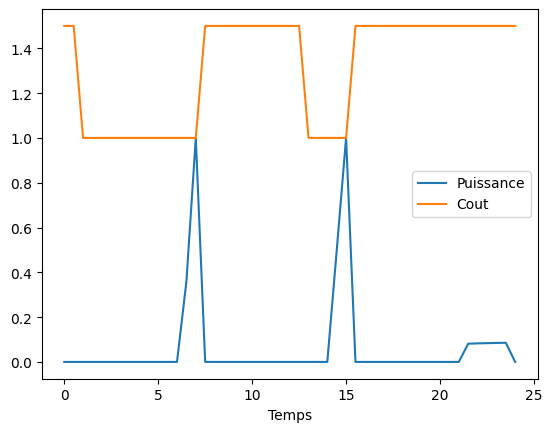

In [28]:
plt.plot(temps_heures,np.array(sol_temp['P']/P_M).flatten(), label = "Puissance")
plt.plot(temps_heures,Cout, label = "Cout")
plt.xlabel("Temps")
plt.legend()
plt.show()

7)

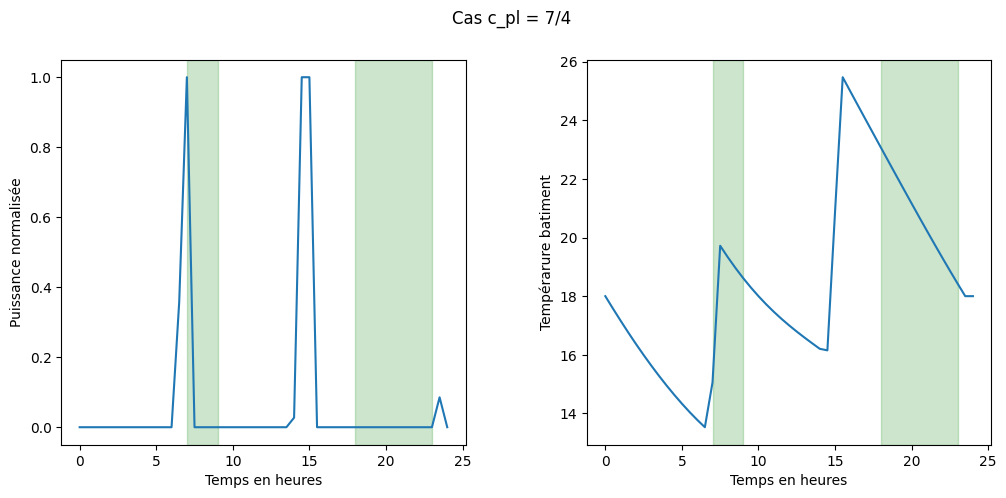

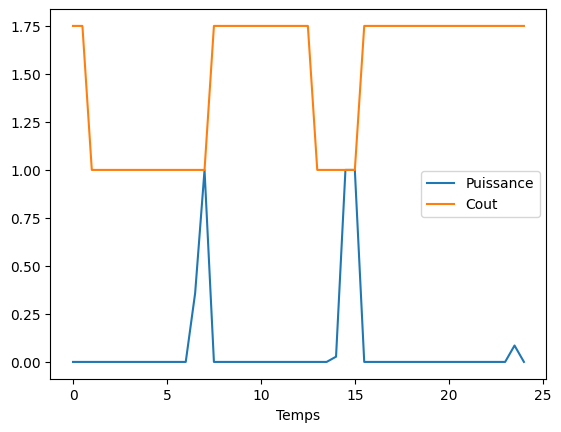

In [34]:
c_pl = 7/4
Cout, temps, i_occur = Coût(c_cr, c_pl,N)
sol_temp = solve_effacement()
temps_heures = np.arange(N+1) * dt # pour avoir le temps en heure
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))  
fig.subplots_adjust(wspace=0.3)  
axs[0].plot(temps_heures,np.array(sol_temp['P']/P_M).flatten())
axs[0].axvspan(7,9, color = "green", alpha = 0.2, label = "occupé")
axs[0].axvspan(18,23, color = "green", alpha = 0.2)

axs[1].plot(temps_heures,np.array(sol_temp['T']).flatten())
axs[1].axvspan(7,9, color = "green", alpha = 0.2, label = "occupé")
axs[1].axvspan(18,23, color = "green", alpha = 0.2)
axs[0].set_ylabel("Puissance normalisée")
axs[0].set_xlabel("Temps en heures")
#axs[1].plot(sol_temp['T'].T)
axs[1].set_ylabel("Tempérarure batiment")
axs[1].set_xlabel("Temps en heures")
fig.suptitle("Cas c_pl = 7/4")
plt.show()
plt.plot(temps_heures,np.array(sol_temp['P']/P_M).flatten(), label = "Puissance")
plt.plot(temps_heures,Cout, label = "Cout")
plt.xlabel("Temps")
plt.legend()
plt.show()

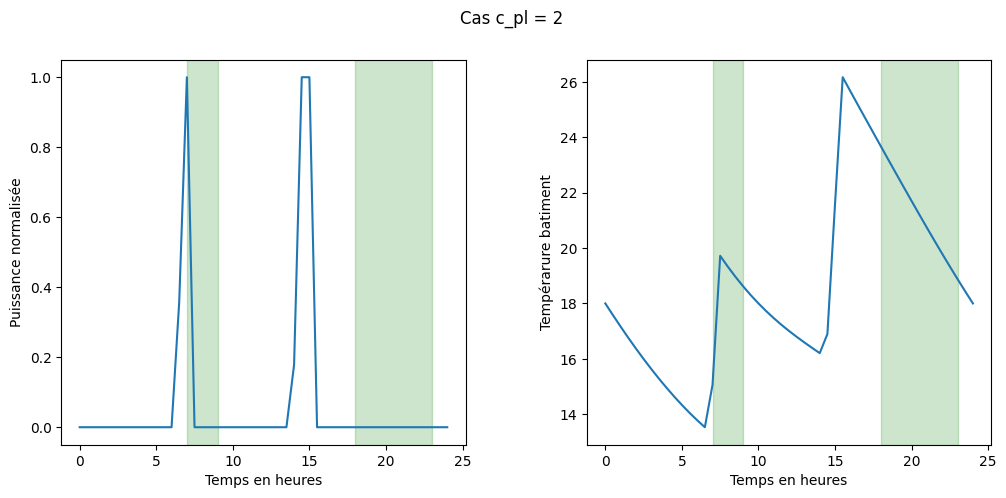

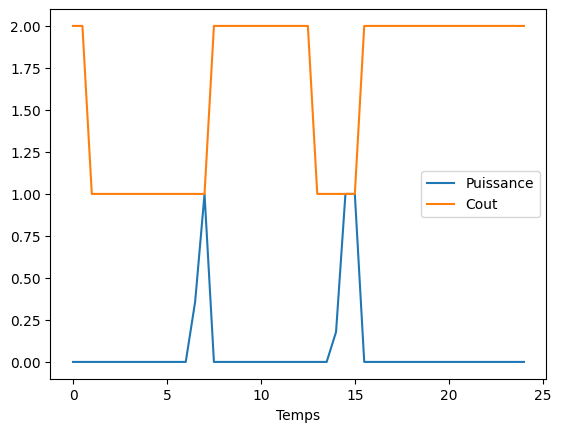

In [35]:
c_pl = 2
Cout, temps, i_occur = Coût(c_cr, c_pl,N)
sol_temp = solve_effacement()
temps_heures = np.arange(N+1) * dt # pour avoir le temps en heure
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))  
fig.subplots_adjust(wspace=0.3)  
axs[0].plot(temps_heures,np.array(sol_temp['P']/P_M).flatten())
axs[0].axvspan(7,9, color = "green", alpha = 0.2, label = "occupé")
axs[0].axvspan(18,23, color = "green", alpha = 0.2)

axs[1].plot(temps_heures,np.array(sol_temp['T']).flatten())
axs[1].axvspan(7,9, color = "green", alpha = 0.2, label = "occupé")
axs[1].axvspan(18,23, color = "green", alpha = 0.2)
axs[0].set_ylabel("Puissance normalisée")
axs[0].set_xlabel("Temps en heures")
#axs[1].plot(sol_temp['T'].T)
axs[1].set_ylabel("Tempérarure batiment")
axs[1].set_xlabel("Temps en heures")
fig.suptitle("Cas c_pl = 2")
plt.show()
plt.plot(temps_heures,np.array(sol_temp['P']/P_M).flatten(), label = "Puissance")
plt.plot(temps_heures,Cout, label = "Cout")
plt.xlabel("Temps")
plt.legend()
plt.show()

## Régulation collective
8) 

9) Partage de la puissance, moins d'énergie consommée?

10) 

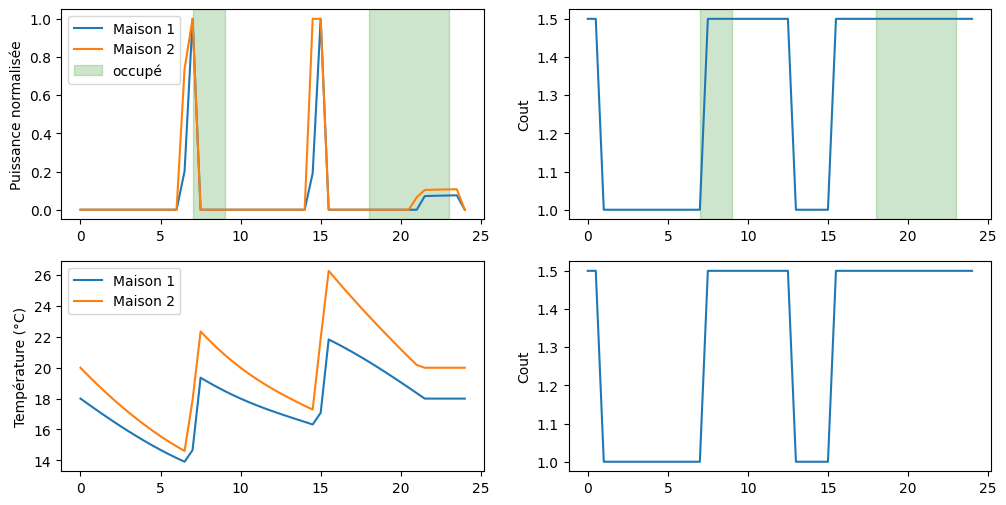

In [38]:
def T_ext(t): 
    return 4 + 8* np.exp(-(t-12)**2/40)
    
def Coût(c_cr,c_pl,N:int):
    t = 23 #heure de départ
    "Construction du coût et des indices d'occurence pour les heures de présence qui seront utilisées par la suite"""
    Cout =[]
    temps = [] 
    i_occur = [] 
    
    for i in range(N+1):
        temps.append(t%24) 
        if 0<= t%24 <=6 or 12<= t%24<=14: #tarif heure creuse
            Cout.append(c_cr)
        elif 6<t%24<12 or 14<t%24<24 : #tarif heure pleine
            Cout.append(c_pl)
            
        if 7<=t%24<=9 or 18<=t%24<=23: # indice des horaires de présence 
            i_occur.append(i) 
            
        t+=dt
    return Cout, temps, i_occur

c_cr = 1
c_pl = 3/2
dt = 0.5
N = int(24/dt)
t_0= 23
P_M = 5000  
T_m1 = 18 # en degré celcius
T_M = 30
T_m2 = 20
T_in1 = T_m1
T_in2 = T_m2
h = 0.05 # en heure -1
k = 0.01 # en heure -1
b = 1/500 # en C/Wh
P_M = 5000 # en Watt
h_12 = h
h_21 = h

dt = 0.5 # en heure
t_0 = 23 
N = int(24/dt) # horizon de temps de 24 h 
Cout, temps, i_occur = Coût(c_cr, c_pl,N)
nl =2  
    
def solve_effacement_bis():

    P = ca.SX.sym('P', N + 1, nl ) 
    T = ca.SX.sym('T', N + 1,nl)
    

    nvar = 2*(N+1)*nl
    lbx = []
    ubx = []
    # Bounds on P
    lbx += [0.0]*(N+1)*nl #pas de distinction entre les maisons dans ce cas
    ubx += [P_M]*(N+1)*nl
    # Bounds on T : il faut gérer les cas où les T sont bornées ou pas
    for n in range(nl): # même si c'est pas optimal
        for i in range (N+1):
            if i in i_occur:
                if n==0:
                    lbx += [T_m1]
                else:
                    lbx += [T_m2]
                    
                ubx += [T_M]
            else:
                lbx += [-np.inf]
                ubx += [np.inf]
            
    


    x = ca.vertcat(
        ca.reshape(P, (N+1)*nl,1),
        ca.reshape(T, (N+1)*nl, 1),
    )

    C = ca.DM(Cout)  # vecteur (N+1,)
    cost = ca.dot(C, P[:N+1,0]) + ca.dot(C, P[:N+1,1])
    
    g=[]
    lbg = []
    ubg = []

    # Constraint 1: température moyenne relation de récurrence
    i = 0

    for i in range(N):
        for j in range(nl):
            if j==0:
                ka = 1
            else:
                ka=0
            g.append(T[i+1,j] - np.exp(-(k+h + h)*dt)*T[i,j]- (1-np.exp(-(k+h+h)*dt))/(k+h +h)*(b*P[i,j] + h*T_ext(temps[i]) + h*T[i,ka])) 
            lbg.append(0.0)
            ubg.append(0.0)

    # Constraint 2: température initiale et puissance terminale
    g.append(T[0,0])
    g.append(T[0,1])
    lbg.append(T_m1)
    ubg.append(T_m1)
    lbg.append(T_m2)
    ubg.append(T_m2)
    g.append(P[N])
    g.append(P[N])
    
    lbg.append(0)
    ubg.append(0)
    lbg.append(0)
    ubg.append(0)

    

    g = ca.vertcat(*g)

    lp =  {'x': x, 'f': cost, 'g': g}
    solver = ca.qpsol('s', 'highs', lp)
    
    # On va chercher à initialiser au mieux nos variables
    
    x0 = ca.DM.ones(nvar)   
    sol =  solver(
        x0 = x0,
        lbx= lbx,
        ubx= ubx,
        lbg= lbg,
        ubg= ubg,
    )

    P = sol['x'][:(N+1)*nl]
    T = sol['x'][(N+1)*nl:]


    return {
        'P' : ca.reshape(P, N+1, nl),
        'T' : ca.reshape(T, N+1, nl),
        
    }


sol_temp_bis = solve_effacement_bis()
P_np = sol_temp_bis["P"]
T_np = sol_temp_bis["T"]

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,6))

# Puissance
axs[0,0].plot(temps_heures, P_np[:,0]/P_M, label="Maison 1")
axs[0,0].plot(temps_heures, P_np[:,1]/P_M, label="Maison 2")
axs[0,0].set_ylabel("Puissance normalisée")
axs[0,0].axvspan(7,9, color = "green", alpha = 0.2, label = "occupé")
axs[0,0].axvspan(18,23, color = "green", alpha = 0.2)
axs[0,0].legend()

# Coût
axs[0,1].plot(temps_heures, Cout)
axs[0,1].axvspan(7,9, color = "green", alpha = 0.2, label = "occupé")
axs[0,1].axvspan(18,23, color = "green", alpha = 0.2)
axs[0,1].set_ylabel("Cout")

# Température
axs[1,0].plot(temps_heures, T_np[:,0], label="Maison 1")
axs[1,0].plot(temps_heures, T_np[:,1], label="Maison 2")
axs[1,0].set_ylabel("Température (°C)")
axs[1,0].legend()


axs[1,1].plot(temps_heures, Cout)
axs[1,1].set_ylabel("Cout")

plt.show()